In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/netflix_titles.csv.zip")

print(df.shape)
print(df.info())
df.head()

(8807, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
df.drop_duplicates(inplace=True)

In [3]:
df[df.duplicated(subset=['title'], keep=False)]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description


In [4]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [5]:
df['director'].fillna("Unknown", inplace=True)

/tmp/ipykernel_860/584041027.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna("Unknown", inplace=True)


In [6]:
df['cast'].fillna("Unknown", inplace=True)

/tmp/ipykernel_860/3915826587.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['cast'].fillna("Unknown", inplace=True)


In [7]:
df['country'].fillna("Not Specified", inplace=True)

/tmp/ipykernel_860/3094761707.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['country'].fillna("Not Specified", inplace=True)


In [8]:
df['rating'].fillna("Not Rated", inplace=True)

/tmp/ipykernel_860/1134614394.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['rating'].fillna("Not Rated", inplace=True)


In [9]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

In [10]:
df['date_added'].fillna(pd.Timestamp("2000-01-01"), inplace=True)

/tmp/ipykernel_860/4294126739.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['date_added'].fillna(pd.Timestamp("2000-01-01"), inplace=True)


In [11]:
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month

In [12]:

mask = df["rating"].str.contains("MIN", na=False)

df.loc[mask, "duration"] = df.loc[mask, "rating"]
df.loc[mask, "rating"] = "Not Rated"

In [13]:
df[["duration_value", "duration_unit"]] = df["duration"].str.split(" ", expand=True)
df["duration_value"] = pd.to_numeric(df["duration_value"], errors="coerce")

In [14]:
df['duration'].fillna("0 min", inplace=True)

/tmp/ipykernel_860/1697680939.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['duration'].fillna("0 min", inplace=True)


In [15]:
df['country'] = df['country'].str.strip()
df['country'] = df['country'].str.split(', ')

In [16]:
df['listed_in'] = df['listed_in'].str.strip()
df['listed_in'] = df['listed_in'].str.split(', ')

In [17]:
df['rating'] = df['rating'].str.upper().str.strip()

In [18]:
df[['duration_value', 'duration_unit']] = df['duration'].str.split(' ', expand=True)

df['duration_value'] = pd.to_numeric(df['duration_value'], errors='coerce')

In [19]:
df_cleaned = df.copy()

In [20]:
df_cleaned.to_csv("netflix_cleaned.csv", index=False)

In [21]:
df_cleaned.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


# MILESTONE - **2**

Feature Engineering

In [22]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month

In [23]:
def categorize_movie_length(row):
    if row["duration_unit"] == "min":
        if row["duration_value"] < 60:
            return "Short Movie"
        elif row["duration_value"] <= 120:
            return "Medium Movie"
        else:
            return "Long Movie"
    return None

df["movie_length_category"] = df.apply(categorize_movie_length, axis=1)

In [24]:
def categorize_tv_length(row):
    if row["duration_unit"] == "Season" or row["duration_unit"] == "Seasons":
        if row["duration_value"] == 1:
            return "Single Season"
        elif row["duration_value"] <= 3:
            return "Limited Series"
        else:
            return "Multi-Season"
    return None

df["tv_length_category"] = df.apply(categorize_tv_length, axis=1)

In [25]:
df["is_original"] = df["title"].str.contains("Netflix", case=False, na=False)

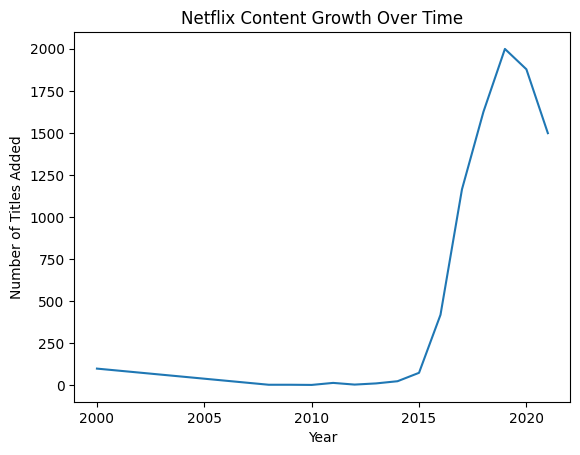

In [26]:
import matplotlib.pyplot as plt

growth = df.groupby("year_added").size()

plt.figure()
growth.plot()
plt.title("Netflix Content Growth Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.show()

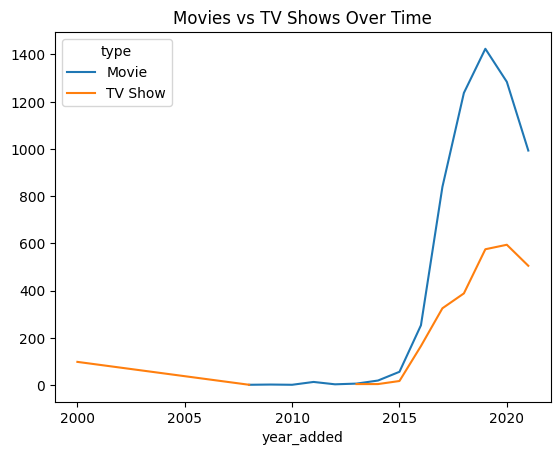

In [27]:
type_growth = df.groupby(["year_added", "type"]).size().unstack()

type_growth.plot()
plt.title("Movies vs TV Shows Over Time")
plt.show()

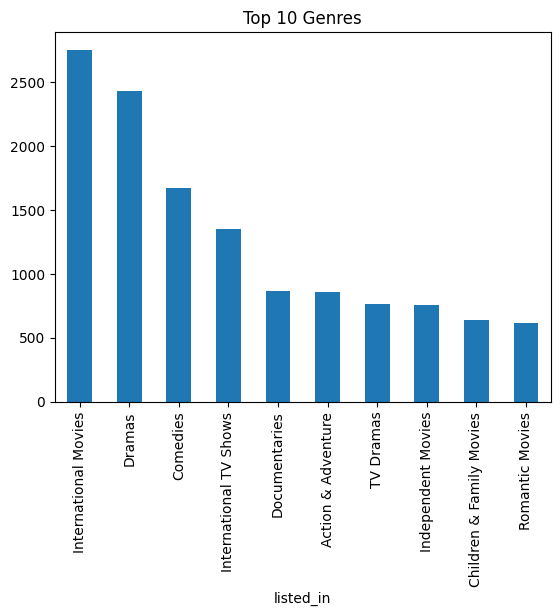

In [28]:
df_genre = df.explode("listed_in")
genre_count = df_genre["listed_in"].value_counts().head(10)
genre_count.plot(kind="bar")
plt.title("Top 10 Genres")
plt.show()

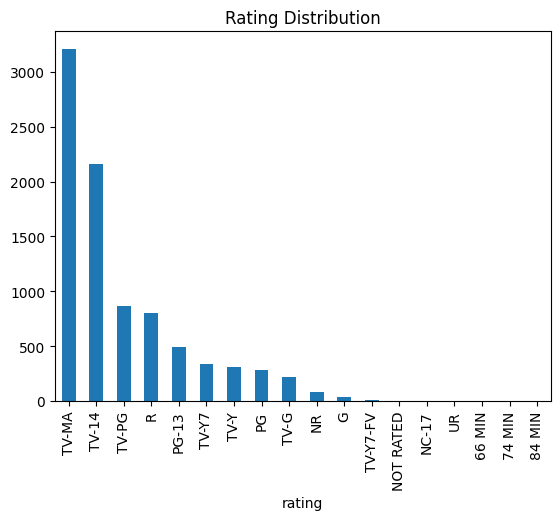

In [29]:
rating_count = df["rating"].value_counts()

rating_count.plot(kind="bar")
plt.title("Rating Distribution")
plt.show()

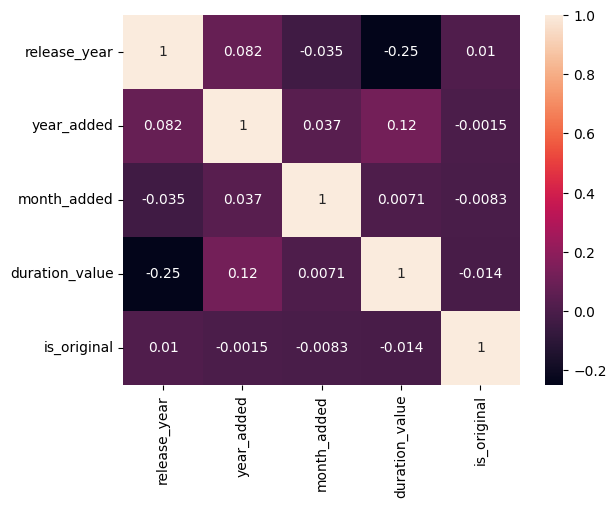

In [30]:
import seaborn as sns

sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

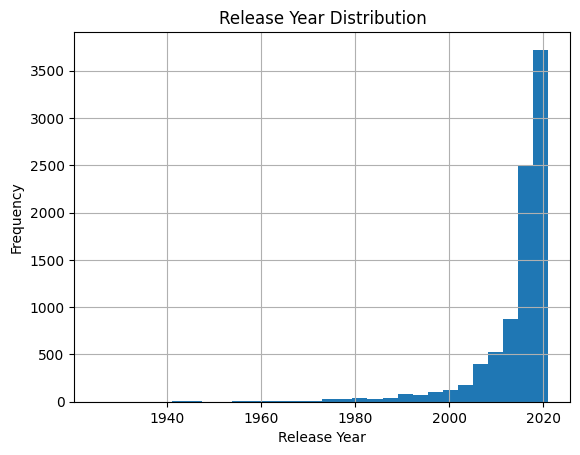

In [31]:
df["release_year"].hist(bins=30)
plt.title("Release Year Distribution")
plt.xlabel("Release Year")
plt.ylabel("Frequency")
plt.show()

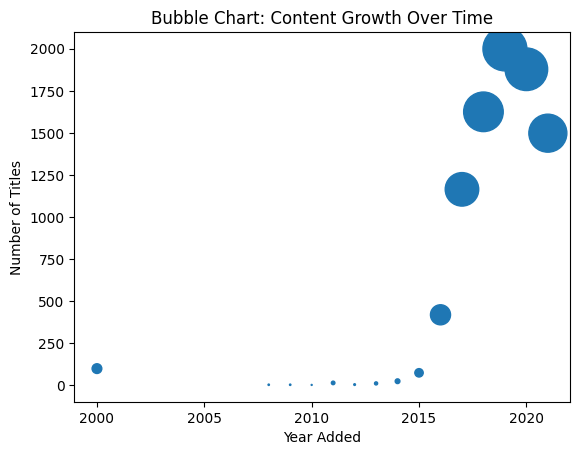

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import ast

df = pd.read_csv("netflix_cleaned.csv")

df["country"] = df["country"].apply(ast.literal_eval)
df["listed_in"] = df["listed_in"].apply(ast.literal_eval)

df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")
df["year_added"] = df["date_added"].dt.year

# Bubble chart
year_counts = df["year_added"].value_counts().sort_index()

plt.figure()
plt.scatter(
    year_counts.index,
    year_counts.values,
    s=year_counts.values * 0.5
)
plt.title("Bubble Chart: Content Growth Over Time")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.show()

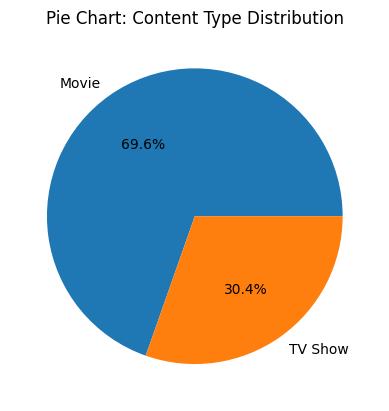

In [33]:
type_counts = df["type"].value_counts()

plt.figure()
plt.pie(
    type_counts.values,
    labels=type_counts.index,
    autopct="%1.1f%%"
)
plt.title("Pie Chart: Content Type Distribution")
plt.show()

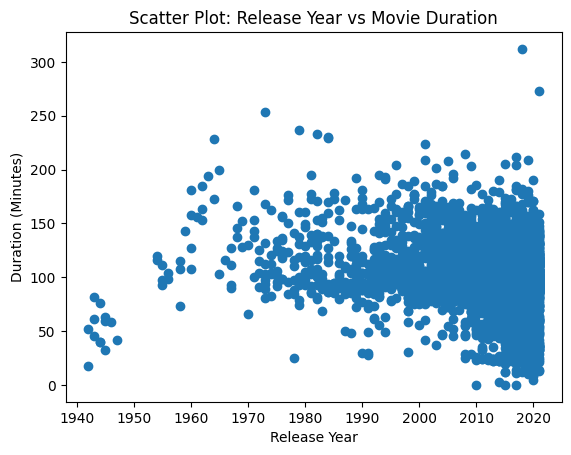

In [34]:
movies = df[df["type"] == "Movie"]

plt.figure()
plt.scatter(
    movies["release_year"],
    movies["duration_value"]
)
plt.title("Scatter Plot: Release Year vs Movie Duration")
plt.xlabel("Release Year")
plt.ylabel("Duration (Minutes)")
plt.show()

# **MILESTONE-3**

In [35]:
import pandas as pd

df = pd.read_csv("netflix_cleaned.csv")

features = df[[
    "type",
    "release_year",
    "duration_value",
    "rating"
]]

In [36]:
from sklearn.preprocessing import LabelEncoder

le_type = LabelEncoder()
le_rating = LabelEncoder()

features["type"] = le_type.fit_transform(features["type"])
features["rating"] = le_rating.fit_transform(features["rating"])

/tmp/ipykernel_860/1829853883.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features["type"] = le_type.fit_transform(features["type"])
/tmp/ipykernel_860/1829853883.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features["rating"] = le_rating.fit_transform(features["rating"])


In [37]:
from sklearn.cluster import KMeans

X = features[["release_year","duration_value","rating"]]

kmeans = KMeans(n_clusters=4, random_state=42)

features["cluster"] = kmeans.fit_predict(X)

/tmp/ipykernel_860/1264651833.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features["cluster"] = kmeans.fit_predict(X)


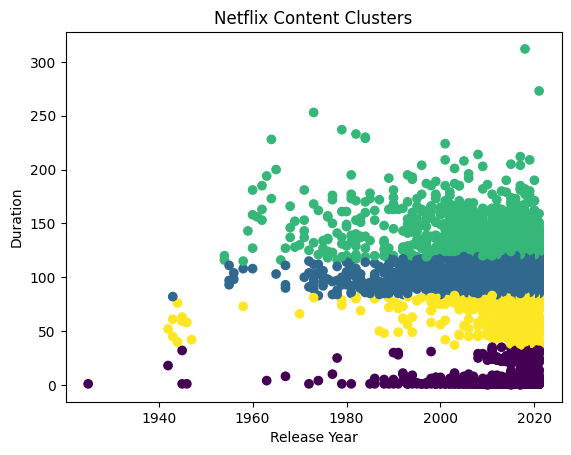

In [38]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(
    features["release_year"],
    features["duration_value"],
    c=features["cluster"]
)
plt.xlabel("Release Year")
plt.ylabel("Duration")
plt.title("Netflix Content Clusters")
plt.show()

In [39]:
from sklearn.model_selection import train_test_split

X = features[["release_year","duration_value","rating"]]
y = features["type"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [40]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

In [41]:
from sklearn.metrics import accuracy_score

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9994324631101021


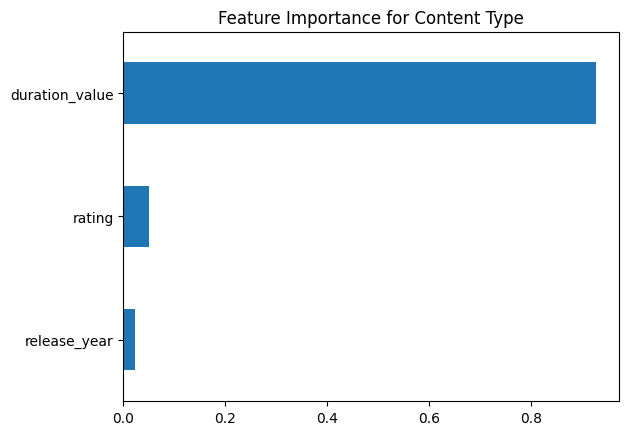

In [43]:
import pandas as pd

importance = pd.Series(model.feature_importances_,index=X.columns)

importance.sort_values().plot(kind="barh")
plt.title("Feature Importance for Content Type")
plt.show()